# AI in Medical Imaging: Brain Tumor Classification

## AIxMED Summer Series – Capstone Project

---

### Team Members
- Abeer Al Dakkak
- Mariam Naim
- Narjes Habib
- Zahraa Younis


# Step 0 — Define the Problem

**Medical Question:**
> Can we accurately classify T1-weighted contrast-enhanced brain MRI slices into three brain tumor types — **Meningioma**, **Glioma**, and **Pituitary tumor** — using CNN, biomedClip, and RAD-DINO?

**ML Setup:**
- **Input (X):** 224 × 224 × 3 brain MRI image tensor after preprocessing (resizing, channel conversion, and normalization).
- **Output (y):** one of 3 tumor classes:
  - Label 1 → Meningioma
  - Label 2 → Glioma
  - Label 3 → Pituitary Tumor
- **Task type:** Multi-class classification

**Why Does This Problem Matter?**
> Clinically, accurate differentiation of brain tumor types from MRI is important because tumor type could assist radiologists by providing a fast and consistent classification of MRI images. Technically, brain MRI contains complex visual patterns and the three tumor classes may have overlapping appearances, making this a challenging multi-class classification problem.

The JCBTD dataset contains MRI slices from 233 patients, providing a realistic medical imaging classification problem for evaluating and comparing different AI models.

**What Does Success Look Like?**
> A successful model should distinguish between the three tumor types while maintaining good performance across all classes, rather than performing well only on the largest class. This is important because the dataset has a moderate class imbalance, with Glioma being more represented than Meningioma and Pituitary Tumor.

We will compare the CNN, BioMedCLIP, and RAD-DINO models using multiple evaluation metrics:

- Macro F1-score — primary metric: Gives equal importance to all three classes and is therefore appropriate for the class imbalance in the dataset.
- Per-class Recall: Measures how effectively the model identifies each tumor type and helps reveal whether the model performs poorly on any particular class.
- Macro AUC: Measures the model's ability to distinguish between the three tumor classes across different classification thresholds.
- Accuracy: Provides an overall measure of the proportion of correctly classified MRI slices.

The models will ultimately be compared on the same unseen test set, and the best-performing model will be determined primarily by Macro F1-score, while considering recall, AUC, and accuracy to provide a more complete evaluation.




##Step 1 — Import Libraries

In [112]:
!pip install open_clip_torch

In [113]:
!pip install -U transformers

In [114]:
import warnings
warnings.filterwarnings('ignore')

import random
from tqdm.notebook import tqdm          # Progress bars
import copy                             # Copy model weights
import numpy as np                      # Numerical operations
import matplotlib.pyplot as plt         # Image visualization and plots
import seaborn as sns                   # Advanced data visualization (e.g., confusion matrix heatmaps)
import pandas as pd
import open_clip

# PyTorch
import torch                             # Deep learning framework
import torch.nn as nn                    # Neural network layers
import torch.optim as optim              # Model optimization
from torch.utils.data import Dataset, DataLoader  # Dataset handling
from torchvision import transforms       # Image preprocessing


# Dataset
from datasets import load_dataset       # Load JCBTD from Hugging Face


# BioMedCLIP and RAD-DINO
from transformers import AutoModel, AutoProcessor, AutoImageProcessor # Hugging Face tools for loading and preprocessing pretrained medical vision models

# Evaluation metrics
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,                     # Overall accuracy
    precision_score,                    # Correct positive predictions
    recall_score,                       # Detected true cases
    f1_score,                           # Balance of precision and recall
    precision_recall_fscore_support,    # Precision/recall/F1 in one call
    classification_report,              # Per-class precision/recall/F1 summary
    confusion_matrix,                   # Prediction errors
    ConfusionMatrixDisplay,              # Confusion matrix visualization
    roc_curve, auc, roc_auc_score,
)

print("Libraries imported successfully!")

Libraries imported successfully!


##Step 2 — Load the Dataset

In [115]:
print("Loading JCBTD from Hugging Face...")
ds = load_dataset("chehablab/JCBTD", split="train") # Load the JCBTD dataset from Hugging Face

print(f"Dataset loaded successfully: {len(ds)} slices") # Display the total number of MRI slices


class_names = ['Meningioma', 'Glioma', 'Pituitary Tumor'] # Define the three tumor classes

num_classes = len(class_names) # Store the total number of classes

# Map the dataset's numeric labels to tumor names
label_map = {
    1: 'Meningioma',
    2: 'Glioma',
    3: 'Pituitary Tumor'
}

Loading JCBTD from Hugging Face...
Dataset loaded successfully: 3064 slices


##Step 3 — Data Preparation & Exploration

###3.1. Data Visualization

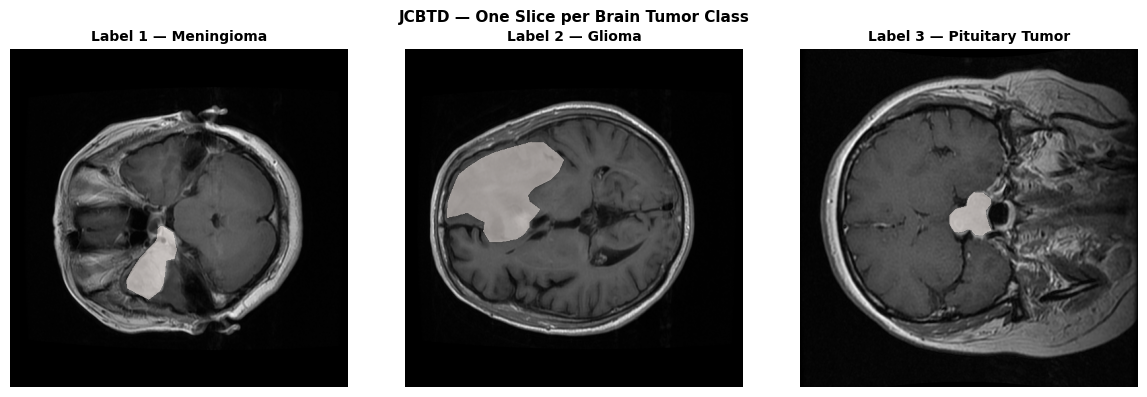

Image mode: L
Image size: (512, 512) (width × height)


In [116]:
samples = {} # Store one sample from each tumor class

for row in ds:
    lbl = row['label']

    # Add the first sample found for each class
    if lbl not in samples:
        samples[lbl] = row

    if len(samples) == num_classes: # Stop once we have one sample for every class
        break

fig, axes = plt.subplots(1, num_classes, figsize=(12, 4)) # Create one subplot for each tumor class

for ax, (lbl, row) in zip(axes, sorted(samples.items())): # Display each MRI slice and its tumor mask

    img_array = np.array(row['image']) # Convert the MRI image to a NumPy array

    ax.imshow(img_array, cmap='gray') # Display the MRI slice in grayscale

    mask_array = np.array(row['mask']) # Convert the tumor mask to a NumPy array

    masked_tumor = np.ma.masked_where(mask_array == 0, mask_array) # Hide the background and keep only the tumor region

    ax.imshow(masked_tumor, cmap='Reds', alpha=0.5) # Overlay the tumor region on the MRI image

    # Add the tumor class as the title
    ax.set_title(
        f"Label {lbl} — {label_map[lbl]}",
        fontweight='bold',
        fontsize=10
    )

    ax.axis('off') # Remove the axes because image coordinates are not needed


# Add a title for the complete figure
plt.suptitle(
    'JCBTD — One Slice per Brain Tumor Class',
    fontweight='bold',
    fontsize=11
)

plt.tight_layout() # Adjust spacing between the subplots

plt.show() # Display the visualization

# Display the image format and dimensions
# Image mode indicates the color format (L = grayscale, RGB, CMYK)
print("Image mode:", samples[1]['image'].mode)
print("Image size:", samples[1]['image'].size, "(width × height)")

###3.2. Dataset overview

--- Dataset Information ---
Total Number of Samples: 3064

--- Dataset Columns ---
- slice_id
- image
- mask
- label

--- Dataset Features ---
- slice_id : Value('int32')
- image : Image(mode=None, decode=True)
- mask : Image(mode=None, decode=True)
- label : Value('int32')

--- Class Information ---
Number of classes: 3
Label 1 → Meningioma
Label 2 → Glioma
Label 3 → Pituitary Tumor


--- Dataset Head (First 5 Rows) ---
 Index  Raw Label Tumor Name Image Size Image Mode
     0          1 Meningioma (512, 512)          L
     1          1 Meningioma (512, 512)          L
     2          1 Meningioma (512, 512)          L
     3          1 Meningioma (512, 512)          L
     4          1 Meningioma (512, 512)          L


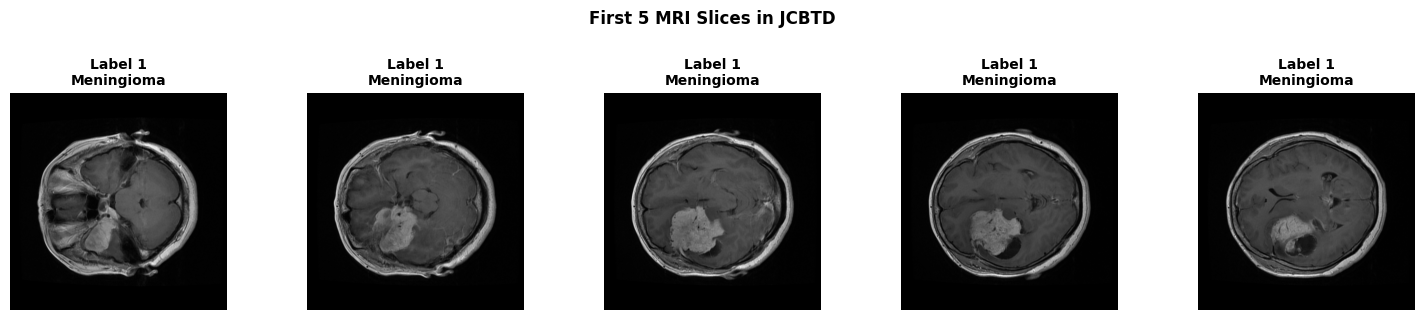

In [117]:
# Display the total number of samples in the dataset
print("--- Dataset Information ---")
print("Total Number of Samples:", len(ds))


# Display the columns stored for each MRI slice
print("\n--- Dataset Columns ---")
for column in ds.column_names:
    print("-", column)


# Display each feature and its data type
print("\n--- Dataset Features ---")
for feature, value in ds.features.items():
    print("-", feature, ":", value)


# Display the number of classes and their corresponding labels
print("\n--- Class Information ---")
print("Number of classes:", num_classes)

for label, name in label_map.items():
    print("Label", label, "→", name)

print("\n")


# Display metadata for the first five samples
print("--- Dataset Head (First 5 Rows) ---")

head_data = []

for i in range(5):
    row = ds[i]

    # Store basic information about each sample
    head_data.append({
        "Index": i,
        "Raw Label": row['label'],
        "Tumor Name": label_map[row['label']],
        "Image Size": row['image'].size,
        "Image Mode": row['image'].mode
    })

df_head = pd.DataFrame(head_data) # Convert the sample information into a DataFrame

print(df_head.to_string(index=False)) # Display the table without the DataFrame index

fig, axes = plt.subplots(1, 5, figsize=(15, 3)) # Display the first five MRI slices for visual inspection

for i in range(5):
    row = ds[i]

    img_array = np.array(row['image']) # Convert the MRI image to a NumPy array

    lbl = row['label'] # Get the tumor class label

    axes[i].imshow(img_array, cmap='gray') # Display the MRI slice in grayscale

    # Add the tumor class as the title
    axes[i].set_title(
        f"Label {lbl}\n{label_map[lbl]}",
        fontsize=10,
        fontweight='bold'
    )

    axes[i].axis('off') # Hide the axes

# Add a title for the complete figure
plt.suptitle(
    "First 5 MRI Slices in JCBTD",
    fontweight='bold',
    fontsize=12,
    y=1.05
)

plt.tight_layout() # Adjust spacing between the images

plt.show() # Display the images

###3.3. Class Distribution Analysis

JCBTD Class Imbalance Distribution

Label 1 - Meningioma : 708 slices ( 23.11 %)
Label 2 - Glioma : 1426 slices ( 46.54 %)
Label 3 - Pituitary Tumor : 930 slices ( 30.35 %)


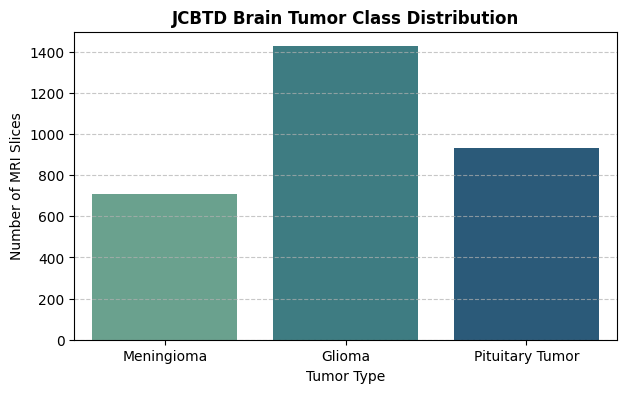

In [118]:
from collections import Counter

raw_counts = Counter(ds['label']) # Count the number of MRI slices belonging to each tumor class

total_samples = len(ds) # Get the total number of MRI slices

# Display the number and percentage of samples in each class
print("JCBTD Class Imbalance Distribution\n")

for lbl in sorted(raw_counts):

    count = raw_counts[lbl] # Get the number of samples in the current class

    pct = (count / total_samples) * 100 # Calculate the percentage of the dataset represented by this class

    print(
        "Label", lbl,
        "-", label_map[lbl],
        ":", count,
        "slices (", round(pct, 2), "%)"
    )


# Prepare class names and counts for the bar plot
plot_labels = [label_map[lbl] for lbl in sorted(raw_counts)]
plot_counts = [raw_counts[lbl] for lbl in sorted(raw_counts)]


# Create a bar plot to visualize the class distribution
plt.figure(figsize=(7, 4))

sns.barplot(
    x=plot_labels,
    y=plot_counts,
    palette="crest"
)

# Add plot title and axis labels
plt.title(
    "JCBTD Brain Tumor Class Distribution",
    fontweight='bold'
)
plt.xlabel("Tumor Type")
plt.ylabel("Number of MRI Slices")

# Add horizontal grid lines to make counts easier to compare
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

##Step 3 — Split into Train / Validation / Test

In [8]:
split1   = ds.train_test_split(test_size=0.2, seed=42) #20% test
split2   = split1['train'].train_test_split(test_size=0.25, seed=42) #Split the remaining 80% into 75% training and 25% validation

train = split2['train']   # 60% (75% of 80% train)
val   = split2['test']    # 20% (25% of 80% train)
test  = split1['test']    # 20%

# Display the number of slices in each split
print(f"Train      : {len(train):>5} slices (60%)")
print(f"Validation : {len(val):>5} slices (20%)")
print(f"Test       : {len(test):>5} slices (20%)")
print(f"Total      : {len(train) + len(val) + len(test):>5} slices")

Train      :  1838 slices (60%)
Validation :   613 slices (20%)
Test       :   613 slices (20%)
Total      :  3064 slices


## Class-Weighted CrossEntropyLoss

### The Clinical Problem:
The JCBTD dataset shows a mild to moderate class imbalance, where Glioma is the most represented class (46.5%), while Meningioma (23.1%) and Pituitary Tumor (30.4%) contain fewer samples.

During training, standard Cross-Entropy Loss treats all classification errors equally. This can cause the model to become biased toward the majority class because it sees more examples from that category and may minimize the loss by predicting the dominant class more frequently.

---

### How Inverse-Frequency Weighting Works:
To reduce the effect of class imbalance, a weight is calculated for each class using the inverse-frequency formula:

$$
w_c = \frac{N}{K \cdot N_c}
$$

where:

- \(N\) = total number of samples in the training set  
- \(K\) = number of classes (3 in this dataset)  
- \(N_c\) = number of samples belonging to class \(c\)  

Classes with fewer samples receive a higher weight, while classes with more samples receive a lower weight.

---

### Impact on Model Optimization:
The calculated weights are passed to PyTorch's `CrossEntropyLoss` function. During training, misclassifying minority classes contributes more to the total loss, encouraging the model to learn features from all tumor categories instead of focusing mainly on the majority class.

This approach can improve performance on underrepresented classes, especially when evaluating with metrics such as **Macro F1-score** and the **confusion matrix**.

In [9]:
# Select GPU if available; otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Convert training labels from 1, 2, 3 to 0, 1, 2
train_labels = [label - 1 for label in train['label']]

# Count the number of training samples in each class
class_counts = np.bincount(
    train_labels,
    minlength=num_classes
)

total_samples = len(train_labels) # Total number of training samples

# Calculate inverse-frequency class weights
# Minority classes receive higher weights.
class_weights = total_samples / (
    num_classes * class_counts.astype(np.float32)
)

# Convert class weights to a PyTorch tensor
# and move them to the selected device
class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

# Display class distribution and corresponding weights
print("\n--- Class Weight Analysis ---")

for idx, (name, count, weight) in enumerate(
    zip(class_names, class_counts, class_weights)
):
    print(
        f"Class {idx} - {name:<18} "
        f"| Samples: {count:>5} "
        f"| Loss Weight: {weight:.4f}"
    )

# Create ONE weighted CrossEntropyLoss
# This loss will be reused by: CNN, BioMedCLIP, RAD-DINO

weighted_criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

print("\nWeighted CrossEntropyLoss configured successfully.")

Using device: cuda

--- Class Weight Analysis ---
Class 0 - Meningioma         | Samples:   443 | Loss Weight: 1.3830
Class 1 - Glioma             | Samples:   836 | Loss Weight: 0.7329
Class 2 - Pituitary Tumor    | Samples:   559 | Loss Weight: 1.0960

Weighted CrossEntropyLoss configured successfully.


## Image Preprocessing

### Image Resizing:
The original JCBTD MRI slices are stored as **512 × 512 grayscale images**. However, deep learning models require a fixed input size. Therefore, images are resized to **224 × 224 pixels** before being provided to the models.

This input size is commonly used by pretrained computer vision architectures, including CNN-based models, BioMedCLIP, and RAD-DINO, allowing compatibility with their expected input dimensions while reducing computational cost.

---

### Tensor Conversion:
After resizing, images are converted from PIL image format into PyTorch tensors using `ToTensor()`.

This conversion changes the image representation from:

- PIL image → PyTorch tensor

and scales pixel intensity values from:

$$
[0,255] \rightarrow [0,1]
$$

allowing the images to be processed by deep learning models.

---

### Image Normalization:

The JCBTD dataset was already preprocessed by the dataset creators, including intensity scaling and conversion to standard image format. However, additional normalization is applied during model preparation to match the input distribution expected by pretrained deep learning architectures such as BioMedCLIP and RAD-DINO. This ensures compatibility with pretrained weights and improves training stability.

---

### Channel Conversion:

The original JCBTD MRI slices are grayscale images with a single intensity channel. Before applying the model-specific preprocessing pipeline, each image is converted from grayscale to RGB, creating three identical channels. This does not add color information; it only provides the three-channel input format required by the model architectures.

In [10]:
image_size = (224, 224) #Target image size for all models

# Normalization values used by pretrained vision models
normalize_mean = [0.485, 0.456, 0.406]
normalize_std = [0.229, 0.224, 0.225]
#   normalize_mean[0] = average Red   pixel value across ImageNet ≈ 0.485
#   normalize_mean[1] = average Green pixel value across ImageNet ≈ 0.456
#   normalize_mean[2] = average Blue  pixel value across ImageNet ≈ 0.406
#   normalize_std     = corresponding per-channel standard deviations


# Training transformations
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale MRI to 3 identical channels
    transforms.Resize(image_size),        # Resize MRI image from 512x512 to 224x224
    transforms.RandomRotation(10),        # Small rotation for data variation
    transforms.ToTensor(),                # Convert image to PyTorch tensor and scale pixels from [0,255] to [0,1]
    transforms.Normalize(                 # Normalize using pretrained model values
        mean=normalize_mean,
        std=normalize_std
    )
])


# Validation/Test transformations (no rotation)
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale MRI to 3 identical channels
    transforms.Resize(image_size),        # Resize MRI image from 512x512 to 224x224
    transforms.ToTensor(),                # Convert image to PyTorch tensor and scale pixels from [0,255] to [0,1]
    transforms.Normalize(                 # Normalize using pretrained model values
        mean=normalize_mean,
        std=normalize_std
    )
])

print("Image preprocessing pipeline created successfully.")

Image preprocessing pipeline created successfully.


##Step 4 — Models: CNN, BiomedCLIP, RAD-DINO

## PyTorch Dataset Wrapper

In [65]:
class JCBTDDataset(Dataset):

    # Set up the dataset.
    # hf_dataset = train, validation, or test split
    # transform = preprocessing pipeline
    # processor = Hugging Face processor such as RAD-DINO
    def __init__(self, hf_dataset, transform=None, processor=None):

        self.dataset = hf_dataset
        self.transform = transform
        self.processor = processor

    # Number of MRI slices
    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        item = self.dataset[idx]

        # Get image and convert it to RGB
        image = item["image"].convert("RGB")

        # Convert labels 1,2,3 → 0,1,2
        label = item["label"] - 1

        # CNN / other torchvision transforms
        if self.transform is not None:

            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

### 4.1 CNN

4.1.1 CNN Dataset Objects

In [12]:
# Create CNN-specific PyTorch Dataset objects.

train_dataset = JCBTDDataset(
    train,
    transform=train_transform
)

val_dataset = JCBTDDataset(
    val,
    transform=eval_transform
)

test_dataset = JCBTDDataset(
    test,
    transform=eval_transform
)

print("CNN Dataset objects created successfully.")

CNN Dataset objects created successfully.


4.1.2 DataLoaders

In [13]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader):>4}  x {BATCH_SIZE} = ~{len(train_dataset):,} slices")
print(f"Val   batches : {len(val_loader):>4}  x {BATCH_SIZE} = ~{len(val_dataset):,} slices")
print(f"Test  batches : {len(test_loader):>4}  x {BATCH_SIZE} = ~{len(test_dataset):,} slices")

# Inspect one batch
imgs, labels = next(iter(train_loader))
print(f"\nBatch image tensor shape : {imgs.shape}   (batch x channels x H x W)")
print(f"Batch label tensor shape : {labels.shape}")

Train batches :   58  x 32 = ~1,838 slices
Val   batches :   20  x 32 = ~613 slices
Test  batches :   20  x 32 = ~613 slices

Batch image tensor shape : torch.Size([32, 3, 224, 224])   (batch x channels x H x W)
Batch label tensor shape : torch.Size([32])


4.1.3 CNN Architecture

In [14]:
class BrainTumorCNN(nn.Module): # creating own neural network called BrainTumorCNN.
# nn.Module is the base class used by PyTorch for neural networks.
    def __init__(self, n_classes=3):
        super().__init__()

        # -- Convolutional backbone -------------------------------------
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),          # 224 -> 112

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),          # 112 -> 56

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),          # 56 -> 28

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),          # 28 -> 14
        )

        self.global_pool = nn.AdaptiveAvgPool2d(1)   # 256 x 14 x 14 -> 256 x 1 x 1

        # -- Classification head -----------------------------------------
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        return self.classifier(x)


# Sanity check - parameter count and output shape
dummy = torch.zeros(1, 3, 224, 224)
_tmp_model = BrainTumorCNN(n_classes=num_classes)
n_params = sum(p.numel() for p in _tmp_model.parameters() if p.requires_grad)
out_shape = _tmp_model(dummy).shape
print(f"CNN — trainable parameters: {n_params:,}   output shape: {out_shape}")
del _tmp_model

CNN — trainable parameters: 422,659   output shape: torch.Size([1, 3])


4.1.4 Training Function

In [15]:
def train_model(model, train_loader, val_loader, criterion, epochs=20, lr=1e-3, device=device):

    # This function trains the CNN model:
      # 1. Trains the model using the training data.
      # 2. Checks the model on the validation data after each epoch.
      # 3. Saves the model weights from the epoch with the best validation accuracy.

    model = model.to(device)     # Move the model to the selected device (GPU if available, otherwise CPU)

    optimizer = optim.Adam(model.parameters(), lr=lr) # Adam is the optimizer that updates the CNN's weights, after each training batch (lr=1e-3 controls how large each weight update is)

    # These lists store the results from every epoch.
    # train_losses -> training loss for each epoch
    # val_accs     -> validation accuracy for each epoch
    train_losses, val_accs = [], []
    best_val_acc = 0.0
    best_state = copy.deepcopy(model.state_dict()) # Save a copy of the model's initial weightsso if the model does not improve during training, we can still return these weights.

    for epoch in tqdm(range(epochs), desc="Training CNN"):

        # -- Training --------------------------------------------------
        model.train()
        epoch_loss = 0.0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)               # forward images to the CNN
            loss = criterion(outputs, labels)     # criterion is our loss function
            loss.backward()                       # calculate gradient
            optimizer.step()                      # Use calculated gradients to update the CNN's weights
            epoch_loss += loss.item()             # .item() converts the PyTorch value into a normal Python number.

        avg_loss = epoch_loss / len(train_loader)

        # -- Validation --------------------------------------------------
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():                    # do not need gradients during validation (only measuring the model's performance)
            for images, labels in val_loader:    # Go through the validation dataset batch by batch.
                images = images.to(device)
                labels = labels.to(device)
                preds = model(images).argmax(dim=1)       # argmax(dim=1) selects the class with the highest score.
                correct += (preds == labels).sum().item() # Compare
                total += labels.size(0)

        val_acc = correct / total           # Calculate validation accuracy
        # Save this epoch's training loss and validation accuracy
        train_losses.append(avg_loss)
        val_accs.append(val_acc)

        # save the best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f"  Epoch {epoch+1:>2}/{epochs}  —  Loss: {avg_loss:.4f}   Val Acc: {val_acc*100:.2f}%")

    model.load_state_dict(best_state) # replace the current weights with the weights from the epoch that had the highest validation accuracy
    return model, train_losses, val_accs, best_val_acc

print("Training function defined.")

Training function defined.


4.1.5 Train the CNN

In [59]:
EPOCHS = 20

torch.manual_seed(42) # Set the random seed so the training is more reproducible
cnn_model = BrainTumorCNN(n_classes=num_classes)

print("=" * 55)
print("  Training CNN on JCBTD (Brain Tumor Classification)")
print("=" * 55)

cnn_model, train_losses, val_accs, best_val_acc = train_model(
    cnn_model,
    train_loader,
    val_loader,
    weighted_criterion,   # weighted loss fct created earlier
    epochs=EPOCHS,
    lr=1e-4,              # Learning rate
    device=device
)

# Display the highest validation accuracy achieved during training
print(f"\nBest Validation Accuracy → {best_val_acc*100:.2f}%")

  Training CNN on JCBTD (Brain Tumor Classification)


Training CNN:   0%|          | 0/20 [00:00<?, ?it/s]

  Epoch  1/20  —  Loss: 0.8730   Val Acc: 64.76%
  Epoch  2/20  —  Loss: 0.7166   Val Acc: 75.20%
  Epoch  3/20  —  Loss: 0.6359   Val Acc: 78.30%
  Epoch  4/20  —  Loss: 0.5808   Val Acc: 75.20%
  Epoch  5/20  —  Loss: 0.5296   Val Acc: 76.51%
  Epoch  6/20  —  Loss: 0.4827   Val Acc: 75.86%
  Epoch  7/20  —  Loss: 0.4541   Val Acc: 72.10%
  Epoch  8/20  —  Loss: 0.4029   Val Acc: 84.83%
  Epoch  9/20  —  Loss: 0.4075   Val Acc: 66.88%
  Epoch 10/20  —  Loss: 0.3783   Val Acc: 74.23%
  Epoch 11/20  —  Loss: 0.3788   Val Acc: 84.50%
  Epoch 12/20  —  Loss: 0.3599   Val Acc: 67.86%
  Epoch 13/20  —  Loss: 0.3784   Val Acc: 87.60%
  Epoch 14/20  —  Loss: 0.3454   Val Acc: 87.28%
  Epoch 15/20  —  Loss: 0.3372   Val Acc: 80.26%
  Epoch 16/20  —  Loss: 0.3303   Val Acc: 81.89%
  Epoch 17/20  —  Loss: 0.3447   Val Acc: 66.88%
  Epoch 18/20  —  Loss: 0.3331   Val Acc: 87.11%
  Epoch 19/20  —  Loss: 0.3076   Val Acc: 72.43%
  Epoch 20/20  —  Loss: 0.3051   Val Acc: 85.81%

Best Validation Acc

4.1.6 Plot Training Curves

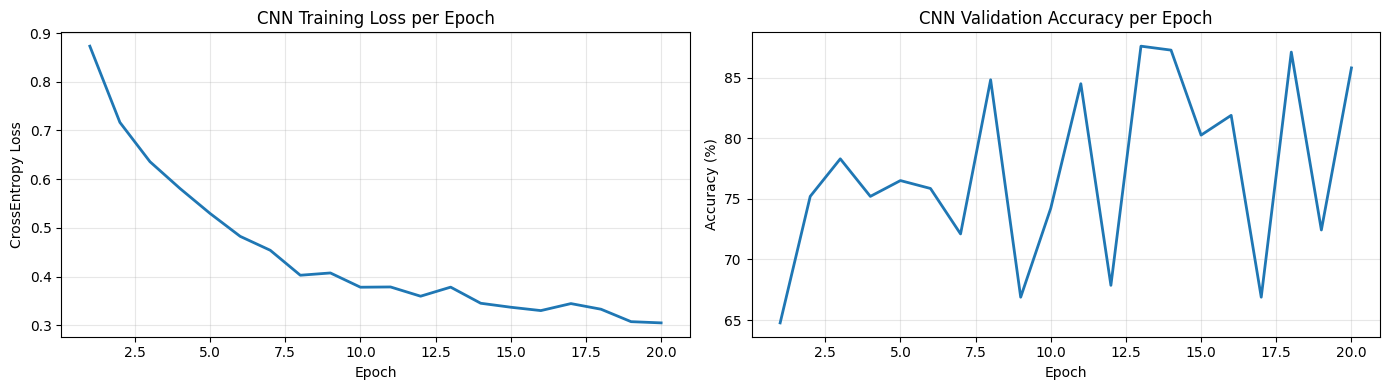

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs_range = range(1, EPOCHS + 1)


# ---------------- Training Loss ----------------

# Plot the average training loss for each epoch
axes[0].plot(
    epochs_range,
    train_losses,
    linewidth=2
)

axes[0].set_title("CNN Training Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].grid(alpha=0.3)


# ---------------- Validation Accuracy ----------------

# Convert validation accuracy from decimal to percentage
val_accuracy_percent = [acc * 100 for acc in val_accs]

# Plot validation accuracy for each epoch
axes[1].plot(
    epochs_range,
    val_accuracy_percent,
    linewidth=2
)

axes[1].set_title("CNN Validation Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout() # Adjust spacing between the two plots
plt.show()

Note: The validation accuracy shows noticeable changes across epochs. This is partly because the dataset contains images from only 233 patients, with multiple MRI slices coming from the same patient. A patient-level split would give a more reliable evaluation by keeping all slices from each patient in the same split. However, the dataset does not provide patient IDs, so the slices cannot be grouped by patient. This is a limitation of the dataset and may contribute to the changes in validation accuracy.

4.1.7 Model Evaluation on the Test Set (once!)

CNN — TEST SET EVALUATION
Accuracy        : 88.25%
Macro Precision : 86.20%
Macro Recall    : 89.07%
Macro F1-score  : 87.15%
Macro AUROC     : 0.9713

Per-Class Results
------------------------------------------------------------
Meningioma          Precision:  71.60%   Recall:  88.55%   F1:  79.18%
Glioma              Precision:  98.09%   Recall:  84.82%   F1:  90.97%
Pituitary Tumor     Precision:  88.89%   Recall:  93.85%   F1:  91.30%


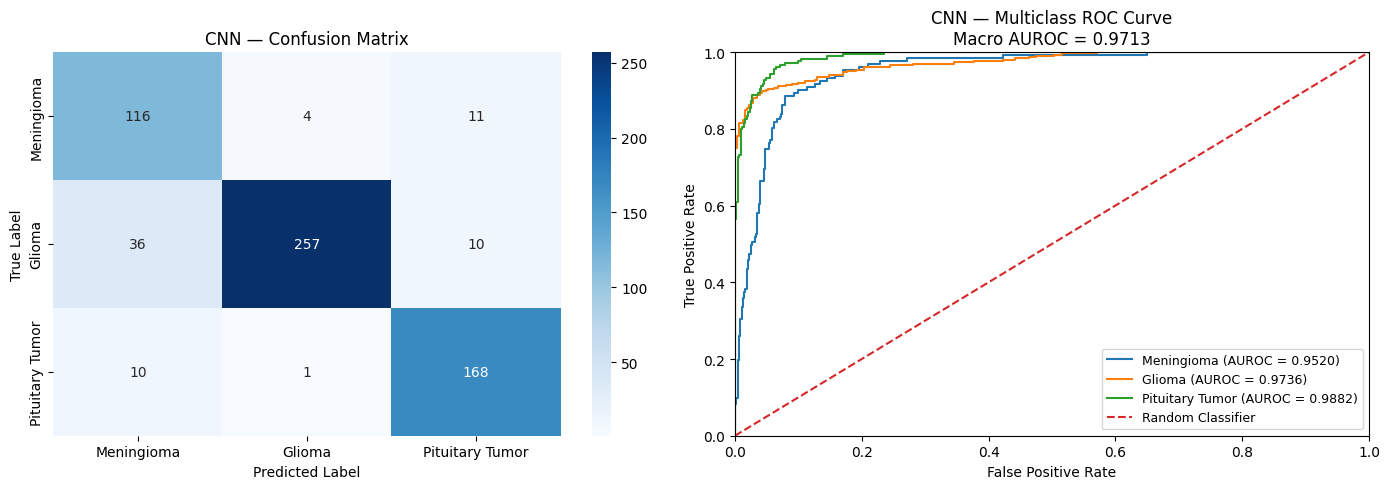

In [156]:
# ============================================================
# CNN — TEST SET EVALUATION
# ============================================================

# Put CNN in evaluation mode
cnn_model.eval()

# Lists to store CNN results
cnn_all_labels = []
cnn_all_preds = []
cnn_all_probs = []

# Run CNN on the TEST set
with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Get model outputs
        outputs = cnn_model(images)

        # Convert logits into probabilities
        cnn_probabilities = torch.softmax(outputs, dim=1)

        # Select the class with the highest probability
        cnn_predictions = torch.argmax(
            cnn_probabilities,
            dim=1
        )

        # Store results
        cnn_all_labels.extend(labels.cpu().numpy())
        cnn_all_preds.extend(cnn_predictions.cpu().numpy())
        cnn_all_probs.extend(cnn_probabilities.cpu().numpy())


# Convert lists to NumPy arrays
cnn_all_labels = np.array(cnn_all_labels)
cnn_all_preds = np.array(cnn_all_preds)
cnn_all_probs = np.array(cnn_all_probs)


# Class names
class_names = [
    "Meningioma",
    "Glioma",
    "Pituitary Tumor"
]


# ------------------------------------------------------------
# Overall Test-Set Metrics
# ------------------------------------------------------------

cnn_accuracy = accuracy_score(
    cnn_all_labels,
    cnn_all_preds
)

cnn_precision = precision_score(
    cnn_all_labels,
    cnn_all_preds,
    average="macro",
    zero_division=0
)

cnn_recall = recall_score(
    cnn_all_labels,
    cnn_all_preds,
    average="macro",
    zero_division=0
)

cnn_f1 = f1_score(
    cnn_all_labels,
    cnn_all_preds,
    average="macro",
    zero_division=0
)

# Multiclass AUROC using One-vs-Rest
cnn_auroc = roc_auc_score(
    cnn_all_labels,
    cnn_all_probs,
    multi_class="ovr",
    average="macro"
)


# ------------------------------------------------------------
# Per-Class Metrics
# ------------------------------------------------------------

cnn_class_precision = precision_score(
    cnn_all_labels,
    cnn_all_preds,
    average=None,
    zero_division=0
)

cnn_class_recall = recall_score(
    cnn_all_labels,
    cnn_all_preds,
    average=None,
    zero_division=0
)

cnn_class_f1 = f1_score(
    cnn_all_labels,
    cnn_all_preds,
    average=None,
    zero_division=0
)


# ------------------------------------------------------------
# Display Results
# ------------------------------------------------------------

print("=" * 60)
print("CNN — TEST SET EVALUATION")
print("=" * 60)

print(f"Accuracy        : {cnn_accuracy * 100:.2f}%")
print(f"Macro Precision : {cnn_precision * 100:.2f}%")
print(f"Macro Recall    : {cnn_recall * 100:.2f}%")
print(f"Macro F1-score  : {cnn_f1 * 100:.2f}%")
print(f"Macro AUROC     : {cnn_auroc:.4f}")


# ------------------------------------------------------------
# Per-Class Results
# ------------------------------------------------------------

print("\nPer-Class Results")
print("-" * 60)

for i, class_name in enumerate(class_names):

    print(
        f"{class_name:<20}"
        f"Precision: {cnn_class_precision[i] * 100:6.2f}%   "
        f"Recall: {cnn_class_recall[i] * 100:6.2f}%   "
        f"F1: {cnn_class_f1[i] * 100:6.2f}%"
    )


# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cnn_cm = confusion_matrix(
    cnn_all_labels,
    cnn_all_preds
)


# ------------------------------------------------------------
# ROC Curves and Per-Class AUROC
# ------------------------------------------------------------

cnn_roc_fpr = {}
cnn_roc_tpr = {}
cnn_class_auroc = {}

for i, class_name in enumerate(class_names):

    cnn_binary_labels = (
        cnn_all_labels == i
    ).astype(int)

    cnn_roc_fpr[i], cnn_roc_tpr[i], _ = roc_curve(
        cnn_binary_labels,
        cnn_all_probs[:, i]
    )

    cnn_class_auroc[i] = roc_auc_score(
        cnn_binary_labels,
        cnn_all_probs[:, i]
    )


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)


# Confusion Matrix
sns.heatmap(
    cnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)

axes[0].set_title(
    "CNN — Confusion Matrix"
)

axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")


# ROC Curves
for i, class_name in enumerate(class_names):

    axes[1].plot(
        cnn_roc_fpr[i],
        cnn_roc_tpr[i],
        label=(
            f"{class_name} "
            f"(AUROC = {cnn_class_auroc[i]:.4f})"
        )
    )

# Random classifier
axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

axes[1].set_title(
    f"CNN — Multiclass ROC Curve\n"
    f"Macro AUROC = {cnn_auroc:.4f}"
)

axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")

axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

axes[1].legend(
    loc="lower right",
    fontsize=9
)

plt.tight_layout()
plt.show()

### 4.2 BiomedClip

4.3.1 Load BioMedClip and its Preprocesing transform

In [62]:
BIOMEDCLIP_NAME = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"

print(f"Loading BioMedCLIP from '{BIOMEDCLIP_NAME}' ...")

#Loading the pre trained model and its preprocessing transform
biomedclip_model, biomedclip_preprocess = open_clip.create_model_from_pretrained(BIOMEDCLIP_NAME)

biomedclip_visual = biomedclip_model.visual #Limiting the model for the visual part only

#Finding the embedding dimension
with torch.no_grad():
    dummy_img = torch.randn(1, 3, 224, 224)
    dummy_embed = biomedclip_visual(dummy_img)
biomedclip_embed_dim = dummy_embed.shape[-1]


print("\nLoaded successfully!")
print(f"  Visual embedding dim : {biomedclip_embed_dim}")
print(f"  Preprocess transform : {biomedclip_preprocess}")

Loading BioMedCLIP from 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224' ...

Loaded successfully!
  Visual embedding dim : 512
  Preprocess transform : Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeConvertMode()
    MaybeToTensor()
    Normalize(mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
)


4.3.2 Build the BioMedClip Linear-Probe Classifier

In [63]:
class BioMedCLIPLinearProbeClassifier(nn.Module):
    '''
    Frozen BioMedCLIP visual encoder + a single trainable Linear(embed_dim -> num_classes) head.
    '''
    def __init__(self, visual_encoder, embed_dim, num_classes):
        super().__init__()
        self.visual_encoder = visual_encoder           #Pre-trained BioMedClip visual encoder
        self.head = nn.Linear(embed_dim, num_classes)  #Trainable classification head

        for param in self.visual_encoder.parameters(): #Freezing parameters of the visual encoder
            param.requires_grad = False

    def forward(self, pixel_values):
        image_features = self.visual_encoder(pixel_values)
        return self.head(image_features)

#Building the classifier using the visual encoder and its embedding size
biomedclip_classifier = BioMedCLIPLinearProbeClassifier(biomedclip_visual, biomedclip_embed_dim, num_classes=3)

#Sanity check: confirm only the head parameters are trainable
total_params     = sum(p.numel() for p in biomedclip_classifier.parameters())
trainable_params = sum(p.numel() for p in biomedclip_classifier.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:>12,}")
print(f"Trainable parameters : {trainable_params:>12,}  (linear head only)")
print(f"Frozen parameters    : {total_params - trainable_params:>12,}")

Total parameters     :   86,193,411
Trainable parameters :        1,539  (linear head only)
Frozen parameters    :   86,191,872


4.3.3 Build the BioMedClip DataLoaders

In [66]:
#Preprocessing for BioMedClip, wrapping each raw data split to return (image,label)
biomedclip_train_ds = JCBTDDataset(train, transform=biomedclip_preprocess)
biomedclip_val_ds   = JCBTDDataset(val,   transform=biomedclip_preprocess)
biomedclip_test_ds  = JCBTDDataset(test,  transform=biomedclip_preprocess)

#Grouping individual samples into batches for training and validation
biomedclip_train_loader = DataLoader(biomedclip_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
biomedclip_val_loader   = DataLoader(biomedclip_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
biomedclip_test_loader  = DataLoader(biomedclip_test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

#Sanity check:
imgs, targets = next(iter(biomedclip_train_loader))
print(f"Batch image shape  : {imgs.shape}   (batch x channels x H x W)")
print(f"Batch target shape : {targets.shape}")
print(f"Sample labels in this batch: {targets[:8].tolist()}")


Batch image shape  : torch.Size([32, 3, 224, 224])   (batch x channels x H x W)
Batch target shape : torch.Size([32])
Sample labels in this batch: [0, 0, 1, 2, 0, 1, 2, 0]


4.3.4 Train the BioMedClip Linear Probe

In [67]:
def train_classifier(model, train_loader, val_loader, epochs=10, lr=1e-3):

    #Use GPU if available, if not use CPU
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    loss_fn = nn.CrossEntropyLoss() #Using cross etropy loss function for classification

    #Only optimizing the linear head's weights, the visual encoder stays frozen
    optimizer = torch.optim.Adam(model.head.parameters(), lr=lr)

    train_losses, val_accuracies = [], [] #Keeping track of training loss and validation accuracy of epochs

    #Variables for keepinng track of the best performing epoch and its weights values
    best_val_acc = 0.0
    best_model_state = None

    epoch_bar = tqdm(range(epochs), desc="Overall Progress") #Generate overall progress bar
    for epoch in epoch_bar:

      #Training:
        model.train()
        running_loss = 0.0

        batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)  #Generate progress bar per epoch
        for imgs, labels in batch_bar:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()           #clear previous gradient calculations
            outputs = model(imgs)           #forward pass: get per-class scores
            loss = loss_fn(outputs, labels) #compare scores to true labels
            loss.backward()                 #compute how to adjust each weight
            optimizer.step()                #actually update the weights

            running_loss += loss.item() * imgs.size(0) #calculate total loss for each epoch
            batch_bar.set_postfix(loss=loss.item())

        #Average loss across all training images seen this epoch
        avg_train_loss = (running_loss / len(train_loader.dataset) )
        train_losses.append(avg_train_loss)

        #Validation:
        model.eval()
        correct, total = 0, 0
        with torch.no_grad(): #Since we are checking performance here, no need for gradients
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                preds = outputs.argmax(dim=-1) #Pick the highest-scoring class per image
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = (correct / total) * 100
        val_accuracies.append(val_acc)

        # Save the model's weights only if this epoch beat every previous epoch
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())

        epoch_bar.set_postfix(train_loss=avg_train_loss, val_acc=val_acc)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.2f}%")

    #Reloading the best-performing weights (not just the last epoch's)
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\nLoaded best model (Val Acc: {best_val_acc:.2f}%)")

    return train_losses, val_accuracies

In [68]:
print("=" * 55)
print("  Training BioMedCLIP Linear Probe (Classification)")
print("=" * 55)
torch.manual_seed(42)
biomedclip_losses, biomedclip_val_accs = train_classifier(
    biomedclip_classifier, biomedclip_train_loader, biomedclip_val_loader, epochs=10, lr=1e-3
)

  Training BioMedCLIP Linear Probe (Classification)


Overall Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10:   0%|          | 0/58 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 0.5827 | Val Acc: 82.87%


Epoch 2/10:   0%|          | 0/58 [00:00<?, ?it/s]

...

Epoch 8/10 | Train Loss: 0.2453 | Val Acc: 87.28%


Epoch 9/10:   0%|          | 0/58 [00:00<?, ?it/s]

Epoch 9/10 | Train Loss: 0.2366 | Val Acc: 89.72%


Epoch 10/10:   0%|          | 0/58 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.2570 | Val Acc: 89.07%

Loaded best model (Val Acc: 89.72%)


4.3.5 BiomedClip Validation Performance

  BioMedCLIP Linear Probe — Validation Results

Model                                Best Val Acc   Epoch
-------------------------------------------------------
  BioMedCLIP (frozen + linear head)       89.7227       9


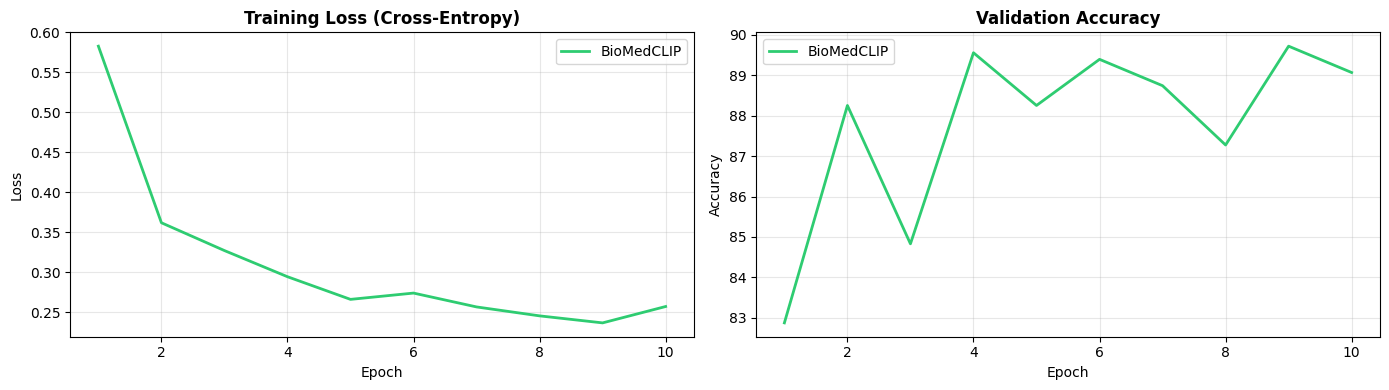

In [69]:
print("=" * 55)
print("  BioMedCLIP Linear Probe — Validation Results")
print("=" * 55)

#Find the best validation accuracy and which epoch it happened on
best_biomedclip_val_acc = max(biomedclip_val_accs)
best_epoch = biomedclip_val_accs.index(best_biomedclip_val_acc) + 1

print(f"\n{'Model':<35}  {'Best Val Acc':>12}  {'Epoch':>6}")
print("-" * 55)
print(f"  {'BioMedCLIP (frozen + linear head)':<33}  {best_biomedclip_val_acc:>12.4f}  {best_epoch:>6}")

#Plotting two charts: training loss and validation accuracy over epochs
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
bmc_epochs = range(1, len(biomedclip_losses) + 1)

axes[0].plot(bmc_epochs, biomedclip_losses, label='BioMedCLIP', color='#2ecc71', linewidth=2)
axes[0].set_title('Training Loss (Cross-Entropy)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(bmc_epochs, biomedclip_val_accs, label='BioMedCLIP', color='#2ecc71', linewidth=2)
axes[1].set_title('Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

4.3.6 Model Evaluation on the Test Set (once!)

BioMedCLIP — TEST SET EVALUATION
Accuracy        : 91.19%
Macro Precision : 89.84%
Macro Recall    : 89.42%
Macro F1-score  : 89.58%
Macro AUROC     : 0.9870

Per-Class Results
------------------------------------------------------------
Meningioma          Precision:  82.22%   Recall:  84.73%   F1:  83.46%
Glioma              Precision:  93.89%   Recall:  96.37%   F1:  95.11%
Pituitary Tumor     Precision:  93.41%   Recall:  87.15%   F1:  90.17%


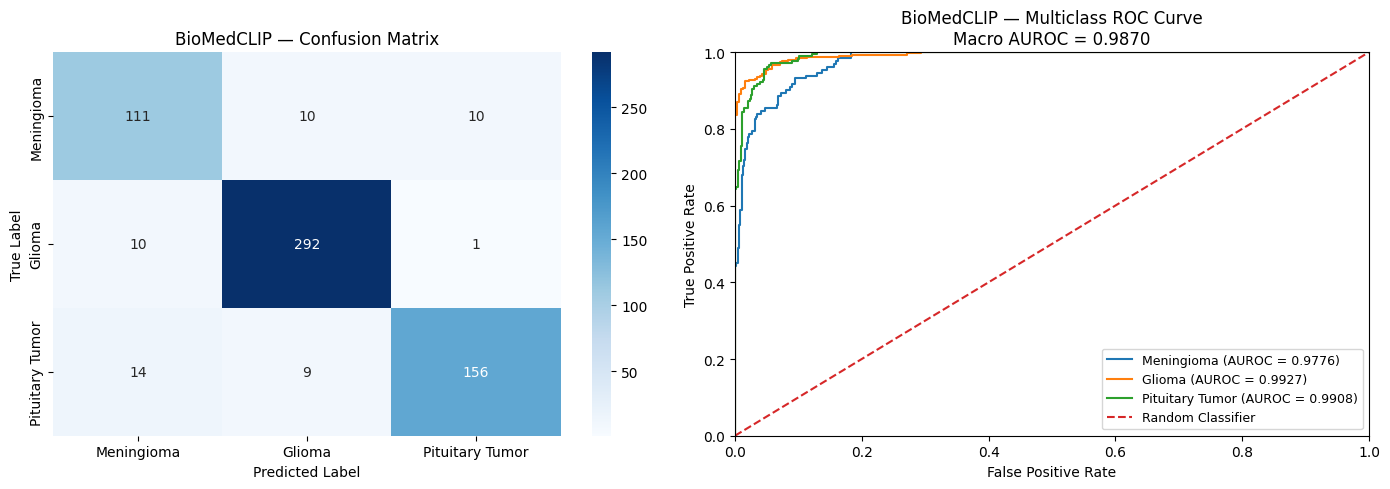

In [155]:
biomedclip_classifier.eval()

# Lists to store BioMedCLIP results
biomedclip_all_labels = []
biomedclip_all_preds = []
biomedclip_all_probs = []

# Run BioMedCLIP on the TEST set
with torch.no_grad():

    for images, labels in biomedclip_test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = biomedclip_classifier(images) # Get model outputs
        biomedclip_probabilities = torch.softmax(outputs, dim=1) # Convert logits into probabilities

        # Select the class with the highest probability
        biomedclip_predictions = torch.argmax(
            biomedclip_probabilities,
            dim=1
        )

        # Store results
        biomedclip_all_labels.extend(labels.cpu().numpy())
        biomedclip_all_preds.extend(biomedclip_predictions.cpu().numpy())
        biomedclip_all_probs.extend(biomedclip_probabilities.cpu().numpy())


# Convert lists to NumPy arrays
biomedclip_all_labels = np.array(biomedclip_all_labels)
biomedclip_all_preds = np.array(biomedclip_all_preds)
biomedclip_all_probs = np.array(biomedclip_all_probs)


# Class names
class_names = [
    "Meningioma",
    "Glioma",
    "Pituitary Tumor"
]

# Test-Set Metrics
biomedclip_accuracy = accuracy_score(
    biomedclip_all_labels,
    biomedclip_all_preds
)

biomedclip_precision = precision_score(
    biomedclip_all_labels,
    biomedclip_all_preds,
    average="macro",
    zero_division=0
)

biomedclip_recall = recall_score(
    biomedclip_all_labels,
    biomedclip_all_preds,
    average="macro",
    zero_division=0
)

biomedclip_f1 = f1_score(
    biomedclip_all_labels,
    biomedclip_all_preds,
    average="macro",
    zero_division=0
)

# Multiclass AUROC using One-vs-Rest
biomedclip_auroc = roc_auc_score(
    biomedclip_all_labels,
    biomedclip_all_probs,
    multi_class="ovr",
    average="macro"
)

# Per-Class Metrics
biomedclip_class_precision = precision_score(
    biomedclip_all_labels,
    biomedclip_all_preds,
    average=None,
    zero_division=0
)

biomedclip_class_recall = recall_score(
    biomedclip_all_labels,
    biomedclip_all_preds,
    average=None,
    zero_division=0
)

biomedclip_class_f1 = f1_score(
    biomedclip_all_labels,
    biomedclip_all_preds,
    average=None,
    zero_division=0
)

# Display Results
print("=" * 60)
print("BioMedCLIP — TEST SET EVALUATION")
print("=" * 60)

print(f"Accuracy        : {biomedclip_accuracy * 100:.2f}%")
print(f"Macro Precision : {biomedclip_precision * 100:.2f}%")
print(f"Macro Recall    : {biomedclip_recall * 100:.2f}%")
print(f"Macro F1-score  : {biomedclip_f1 * 100:.2f}%")
print(f"Macro AUROC     : {biomedclip_auroc:.4f}")

# Per-Class Results
print("\nPer-Class Results")
print("-" * 60)

for i, class_name in enumerate(class_names):

    print(
        f"{class_name:<20}"
        f"Precision: {biomedclip_class_precision[i] * 100:6.2f}%   "
        f"Recall: {biomedclip_class_recall[i] * 100:6.2f}%   "
        f"F1: {biomedclip_class_f1[i] * 100:6.2f}%"
    )

# Confusion Matrix
biomedclip_cm = confusion_matrix(
    biomedclip_all_labels,
    biomedclip_all_preds
)

# ROC Curves and Per-Class AUROC
biomedclip_roc_fpr = {}
biomedclip_roc_tpr = {}
biomedclip_class_auroc = {}

for i, class_name in enumerate(class_names):

    # One-vs-Rest:
    # Current class = 1
    # Other classes = 0
    biomedclip_binary_labels = (
        biomedclip_all_labels == i
    ).astype(int)

    biomedclip_roc_fpr[i], biomedclip_roc_tpr[i], _ = roc_curve(
        biomedclip_binary_labels,
        biomedclip_all_probs[:, i]
    )

    biomedclip_class_auroc[i] = roc_auc_score(
        biomedclip_binary_labels,
        biomedclip_all_probs[:, i]
    )

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)


# Confusion Matrix
sns.heatmap(
    biomedclip_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)

axes[0].set_title(
    "BioMedCLIP — Confusion Matrix"
)

axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")


# ROC Curves
for i, class_name in enumerate(class_names):

    axes[1].plot(
        biomedclip_roc_fpr[i],
        biomedclip_roc_tpr[i],
        label=(
            f"{class_name} "
            f"(AUROC = {biomedclip_class_auroc[i]:.4f})"
        )
    )

# Random classifier
axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

axes[1].set_title(
    f"BioMedCLIP — Multiclass ROC Curve\n"
    f"Macro AUROC = {biomedclip_auroc:.4f}"
)

axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")

axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

axes[1].legend(
    loc="lower right",
    fontsize=9
)

plt.tight_layout()
plt.show()

### 4.3 RAD-DINO

In [119]:
class RadDinoDataset(Dataset):   #This creates a custom PyTorch Dataset called JCBTDDataset.
    def __init__(self, hf_dataset, num_classes, processor=None):
        self.data        = hf_dataset
        self.num_classes = num_classes
        self.processor   = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row    = self.data[idx]
        image  = row['image'].convert('RGB')
        # For multi-class classification, return a single 0-indexed label
        target = row['label'] - 1
        pixel_values = self.processor(image, return_tensors="pt")["pixel_values"][0]
        return pixel_values, target

4.3.1 Loading RAD-DINO

In [120]:
from transformers import AutoImageProcessor, AutoModel # This imports two tools from the Hugging Face transformers library.

RADDINO_NAME = "microsoft/rad-dino"  #Here we're storing the model's name in a variable

# --- RAD-DINO Model Loading ---
print(f"Loading RAD-DINO backbone : {RADDINO_NAME}")
raddino_processor = AutoImageProcessor.from_pretrained(RADDINO_NAME)
raddino_backbone  = AutoModel.from_pretrained(RADDINO_NAME)

Loading RAD-DINO backbone : microsoft/rad-dino


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

4.2.4 Attach a Multi-Label Head & Freeze the Backbone

In [121]:
import torch.nn as nn # Import the neural network module from PyTorch

class MultiClassClassifier(nn.Module):  # Define a new class for a multi-class classifier, inheriting from nn.Module
    def __init__(self, backbone, n_classes):
        super().__init__() # Call the constructor of the parent nn.Module class
        self.backbone = backbone # Store the provided pre-trained backbone model
        hidden        = backbone.config.hidden_size # Get the hidden size (output dimension) from the backbone's configuration
        self.head     = nn.Linear(hidden, n_classes) # Create a linear layer (classification head) mapping hidden features to n_classes

        for p in self.backbone.parameters(): # Iterate through all parameters (weights and biases) of the backbone
            p.requires_grad = False # Freeze the backbone's parameters so they are not updated during training

    def forward(self, pixel_values):
        out = self.backbone(pixel_values=pixel_values) # Pass input pixel values through the frozen backbone model
        cls = out.last_hidden_state[:, 0] # Extract the [CLS] token's representation, typically used for classification
        return self.head(cls) # Pass the [CLS] token's features through the classification head to get the final logits

In [122]:
raddino_clf = MultiClassClassifier(raddino_backbone, num_classes)

In [123]:
raddion_total = sum(p.numel() for p in raddino_clf.parameters())
raddion_trainable = sum(p.numel() for p in raddino_clf.parameters() if p.requires_grad)
print(f"RadDINO | Trainable Parameters {raddion_trainable} | Total Parameters {raddion_total}")

RadDINO | Trainable Parameters 2307 | Total Parameters 86582787


4.2.5 DataLoaders

In [124]:
RAD_BATCH_SIZE = 64 # Decrease it in your case to fit in GPU memory

raddino_train_ds = RadDinoDataset(train, num_classes, processor=raddino_processor) # create our training dataset
raddino_test_ds  = RadDinoDataset(test,  num_classes, processor=raddino_processor) # Create the test dataset
raddino_val_ds   = RadDinoDataset(val,   num_classes, processor=raddino_processor) # Create the validation dataset

raddino_train_dl = DataLoader(raddino_train_ds, batch_size=RAD_BATCH_SIZE, shuffle=True)
raddino_test_dl  = DataLoader(raddino_test_ds,  batch_size=RAD_BATCH_SIZE, shuffle=False)
raddino_val_dl   = DataLoader(raddino_val_ds,   batch_size=RAD_BATCH_SIZE, shuffle=False)

4.2.6 Train the Head

In [125]:
import torch.nn as nn
from sklearn.metrics import roc_auc_score

def train_head(model, train_loader, val_loader, epochs=8, lr=1e-3, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # Use your pre-defined weighted criterion directly
    criterion = weighted_criterion

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )

    train_losses, val_aurocs = [], []
    best_auroc, best_state = -1.0, None

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for pixel_values, targets in (bar := tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")):
            pixel_values, targets = pixel_values.to(device), targets.to(device)
            optimizer.zero_grad()

            # --- FIX 1: Extract logits properly ---
            outputs = model(pixel_values)
            logits = outputs.logits if hasattr(outputs, 'logits') else outputs

            # Calculate loss (works exactly like CNN now!)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            bar.set_postfix({"loss": loss.item()})

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        val_scores, val_targets_list = [], []
        model.eval() # Good practice: set model to eval mode for validation

        with torch.no_grad():
            for pixel_values, targets in (vbar := tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]")):
                pixel_values = pixel_values.to(device)

                # --- FIX 2: Extract logits properly during validation ---
                outputs = model(pixel_values)
                logits = outputs.logits if hasattr(outputs, 'logits') else outputs

                val_scores.append(torch.softmax(logits, dim=1).cpu())
                val_targets_list.append(targets.cpu())

        val_scores = torch.cat(val_scores).numpy()
        val_targets = torch.cat(val_targets_list).numpy()

        # Calculate macro-averaged ROC AUC
        val_auroc = roc_auc_score(
            val_targets,
            val_scores,
            average="macro",
            multi_class='ovr',
            labels=list(range(num_classes)) # Ensure variable matches num_classes
        )
        val_aurocs.append(val_auroc)

        if val_auroc > best_auroc:
            best_auroc = val_auroc
            best_state = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch+1}: train loss={avg_loss:.4f} | val macro-AUROC={val_auroc:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"\nBest val macro-AUROC: {best_auroc:.4f} (restored)")

    return train_losses, val_aurocs

4.2.6 Training Models

4.2.6.2 Train Model RAD-DINO

In [152]:
print("=" * 42)
print("  Training multi-class head on RAD-DINO ")
print("=" * 42)
torch.manual_seed(42)

# class_weights_tensor was already computed once, globally, in the
# "Class-Weighted CrossEntropyLoss" step — reused here exactly as with CNN and BioMedCLIP.
raddino_losses, raddino_val_aurocs = train_head(raddino_clf, raddino_train_dl, raddino_val_dl, epochs=5)

  Training multi-class head on RAD-DINO 


Epoch 1/5 [Train]:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1: train loss=0.3409 | val macro-AUROC=0.9680


Epoch 2/5 [Train]:   0%|          | 0/29 [00:00<?, ?it/s]

...

Epoch 4/5 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 4: train loss=0.3083 | val macro-AUROC=0.9712


Epoch 5/5 [Train]:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 5: train loss=0.3009 | val macro-AUROC=0.9714

Best val macro-AUROC: 0.9714 (restored)


4.2.7 Compare Validation Curves

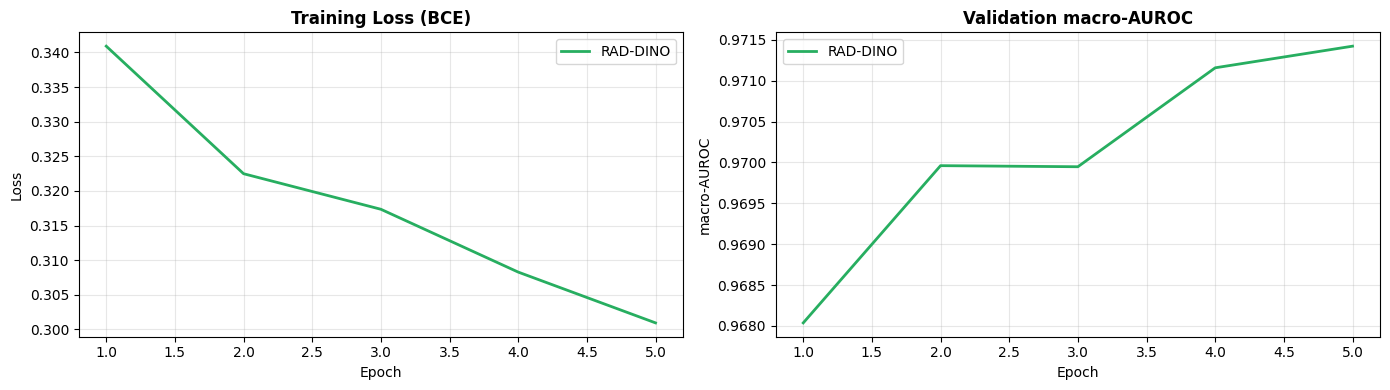

Best val macro-AUROC | RAD-DINO: 0.9714


In [153]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ep_r = range(1, len(raddino_losses) + 1)

axes[0].plot(ep_r, raddino_losses, label="RAD-DINO", color="#27ae60", linewidth=2)
axes[0].set_title("Training Loss (BCE)", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_r, raddino_val_aurocs, label="RAD-DINO", color="#27ae60", linewidth=2)
axes[1].set_title("Validation macro-AUROC", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("macro-AUROC")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best val macro-AUROC | RAD-DINO: {max(raddino_val_aurocs):.4f}")

4.2.8 Model Evaluation on the Test Set (once!)

RAD-DINO — TEST SET EVALUATION
Accuracy        : 88.58%
Macro Precision : 86.90%
Macro Recall    : 88.45%
Macro F1-score  : 87.26%
Macro AUROC     : 0.9754

Per-Class Results
------------------------------------------------------------
Meningioma          Precision:  71.34%   Recall:  89.31%   F1:  79.32%
Glioma              Precision:  95.42%   Recall:  89.44%   F1:  92.33%
Pituitary Tumor     Precision:  93.94%   Recall:  86.59%   F1:  90.12%


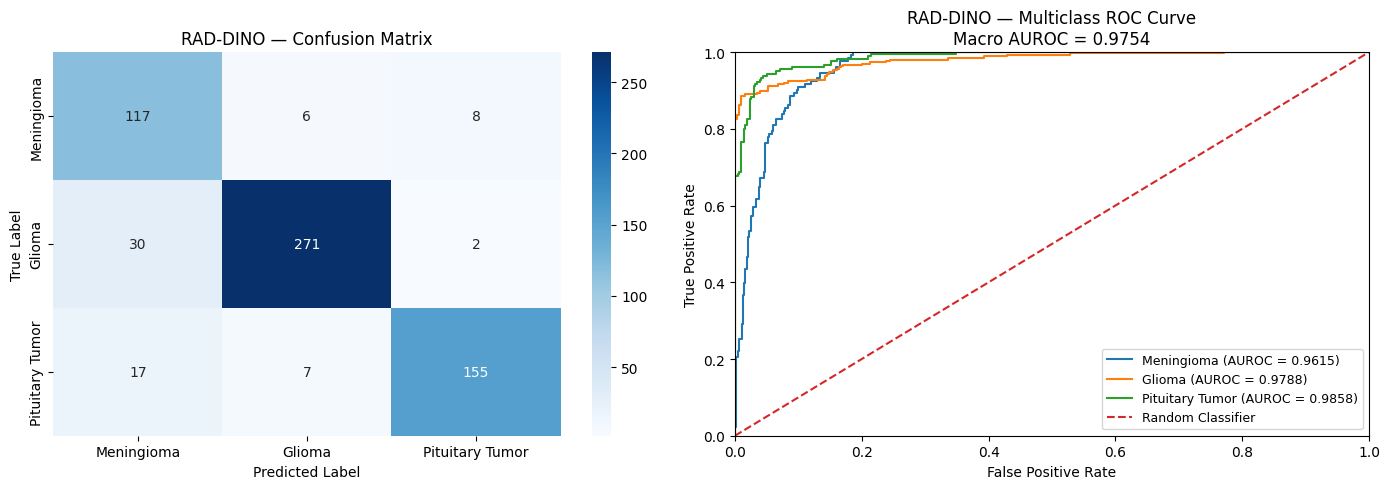

In [166]:
raddino_clf.eval()

raddino_all_labels = []
raddino_all_preds = []
raddino_all_probs = []

# Run RAD-DINO on the TEST set
with torch.no_grad():

    for images, labels in raddino_test_dl:

        images = images.to(device)
        labels = labels.to(device)
        outputs = raddino_clf(images) # Get model outputs

        # Convert logits into probabilities
        raddino_probabilities = torch.softmax(
            outputs,
            dim=1
        )

        # Select the class with the highest probability
        raddino_predictions = torch.argmax(
            raddino_probabilities,
            dim=1
        )

        # Store results
        raddino_all_labels.extend(
            labels.cpu().numpy()
        )

        raddino_all_preds.extend(
            raddino_predictions.cpu().numpy()
        )

        raddino_all_probs.extend(
            raddino_probabilities.cpu().numpy()
        )


# Convert lists to NumPy arrays
raddino_all_labels = np.array(raddino_all_labels)
raddino_all_preds = np.array(raddino_all_preds)
raddino_all_probs = np.array(raddino_all_probs)


# Class names
class_names = [
    "Meningioma",
    "Glioma",
    "Pituitary Tumor"
]

# Metrics
raddino_accuracy = accuracy_score(
    raddino_all_labels,
    raddino_all_preds
)

raddino_precision = precision_score(
    raddino_all_labels,
    raddino_all_preds,
    average="macro",
    zero_division=0
)

raddino_recall = recall_score(
    raddino_all_labels,
    raddino_all_preds,
    average="macro",
    zero_division=0
)

raddino_f1 = f1_score(
    raddino_all_labels,
    raddino_all_preds,
    average="macro",
    zero_division=0
)

# Multiclass AUROC using One-vs-Rest
raddino_auroc = roc_auc_score(
    raddino_all_labels,
    raddino_all_probs,
    multi_class="ovr",
    average="macro"
)

# Per-Class Metrics
raddino_class_precision = precision_score(
    raddino_all_labels,
    raddino_all_preds,
    average=None,
    zero_division=0
)

raddino_class_recall = recall_score(
    raddino_all_labels,
    raddino_all_preds,
    average=None,
    zero_division=0
)

raddino_class_f1 = f1_score(
    raddino_all_labels,
    raddino_all_preds,
    average=None,
    zero_division=0
)

# Display Results
print("=" * 60)
print("RAD-DINO — TEST SET EVALUATION")
print("=" * 60)

print(f"Accuracy        : {raddino_accuracy * 100:.2f}%")
print(f"Macro Precision : {raddino_precision * 100:.2f}%")
print(f"Macro Recall    : {raddino_recall * 100:.2f}%")
print(f"Macro F1-score  : {raddino_f1 * 100:.2f}%")
print(f"Macro AUROC     : {raddino_auroc:.4f}")

# Per-Class Results
print("\nPer-Class Results")
print("-" * 60)

for i, class_name in enumerate(class_names):

    print(
        f"{class_name:<20}"
        f"Precision: {raddino_class_precision[i] * 100:6.2f}%   "
        f"Recall: {raddino_class_recall[i] * 100:6.2f}%   "
        f"F1: {raddino_class_f1[i] * 100:6.2f}%"
    )

# Confusion Matrix
raddino_cm = confusion_matrix(
    raddino_all_labels,
    raddino_all_preds
)

# ROC Curves and Per-Class AUROC
raddino_roc_fpr = {}
raddino_roc_tpr = {}
raddino_class_auroc = {}

for i, class_name in enumerate(class_names):

    # One-vs-Rest labels
    raddino_binary_labels = (
        raddino_all_labels == i
    ).astype(int)

    # ROC curve
    raddino_roc_fpr[i], raddino_roc_tpr[i], _ = roc_curve(
        raddino_binary_labels,
        raddino_all_probs[:, i]
    )

    # Class-specific AUROC
    raddino_class_auroc[i] = roc_auc_score(
        raddino_binary_labels,
        raddino_all_probs[:, i]
    )

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)


# Confusion Matrix
sns.heatmap(
    raddino_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)

axes[0].set_title(
    "RAD-DINO — Confusion Matrix"
)

axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")


# ROC Curves
for i, class_name in enumerate(class_names):

    axes[1].plot(
        raddino_roc_fpr[i],
        raddino_roc_tpr[i],
        label=(
            f"{class_name} "
            f"(AUROC = {raddino_class_auroc[i]:.4f})"
        )
    )

# Random classifier
axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

axes[1].set_title(
    f"RAD-DINO — Multiclass ROC Curve\n"
    f"Macro AUROC = {raddino_auroc:.4f}"
)

axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")

axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

axes[1].legend(
    loc="lower right",
    fontsize=9
)

plt.tight_layout()
plt.show()

##Step 5 — Model Evaluation

5.1 Comparison Table

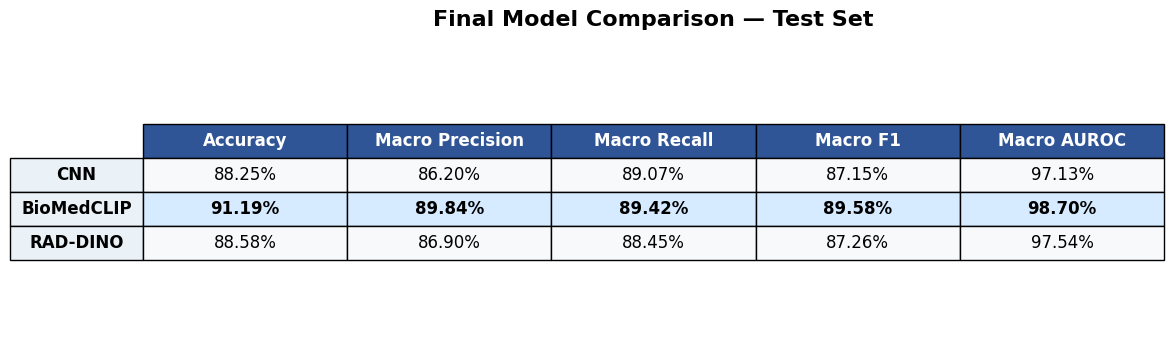

In [169]:
model_results = {
    "CNN": {
        "Accuracy": cnn_accuracy,
        "Macro Precision": cnn_precision,
        "Macro Recall": cnn_recall,
        "Macro F1": cnn_f1,
        "Macro AUROC": cnn_auroc
    },

    "BioMedCLIP": {
        "Accuracy": biomedclip_accuracy,
        "Macro Precision": biomedclip_precision,
        "Macro Recall": biomedclip_recall,
        "Macro F1": biomedclip_f1,
        "Macro AUROC": biomedclip_auroc
    },

    "RAD-DINO": {
        "Accuracy": raddino_accuracy,
        "Macro Precision": raddino_precision,
        "Macro Recall": raddino_recall,
        "Macro F1": raddino_f1,
        "Macro AUROC": raddino_auroc
    }
}

# Create comparison table
summary_df = pd.DataFrame(model_results).T

summary_df = summary_df[
    [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Macro AUROC"
    ]
]

display_df = summary_df.copy()

for column in display_df.columns:
    display_df[column] = display_df[column].map(
        lambda x: f"{x * 100:.2f}%"
    )

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.axis("off")

table = ax.table(
    cellText=display_df.values,
    rowLabels=display_df.index,
    colLabels=display_df.columns,
    cellLoc="center",
    rowLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.0)

for (row, col), cell in table.get_celld().items():

    # Header row
    if row == 0:
        cell.set_facecolor("#2F5597")
        cell.set_text_props(
            color="white",
            weight="bold"
        )

    # Model names
    elif col == -1:
        cell.set_facecolor("#EAF2F8")
        cell.set_text_props(weight="bold")

    # Regular cells
    else:
        cell.set_facecolor("#F8F9FA")

for col_index, column in enumerate(summary_df.columns):

    # Find the model with the highest value
    best_row = summary_df[column].idxmax()

    # Convert model name to table row
    best_row_index = list(summary_df.index).index(best_row) + 1

    # Highlight the best value
    table[(best_row_index, col_index)].set_facecolor("#D6EBFF")
    table[(best_row_index, col_index)].set_text_props(
        weight="bold"
    )

plt.title(
    "Final Model Comparison — Test Set",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.savefig(
    "model_comparison_table.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Bar Chart Visualization

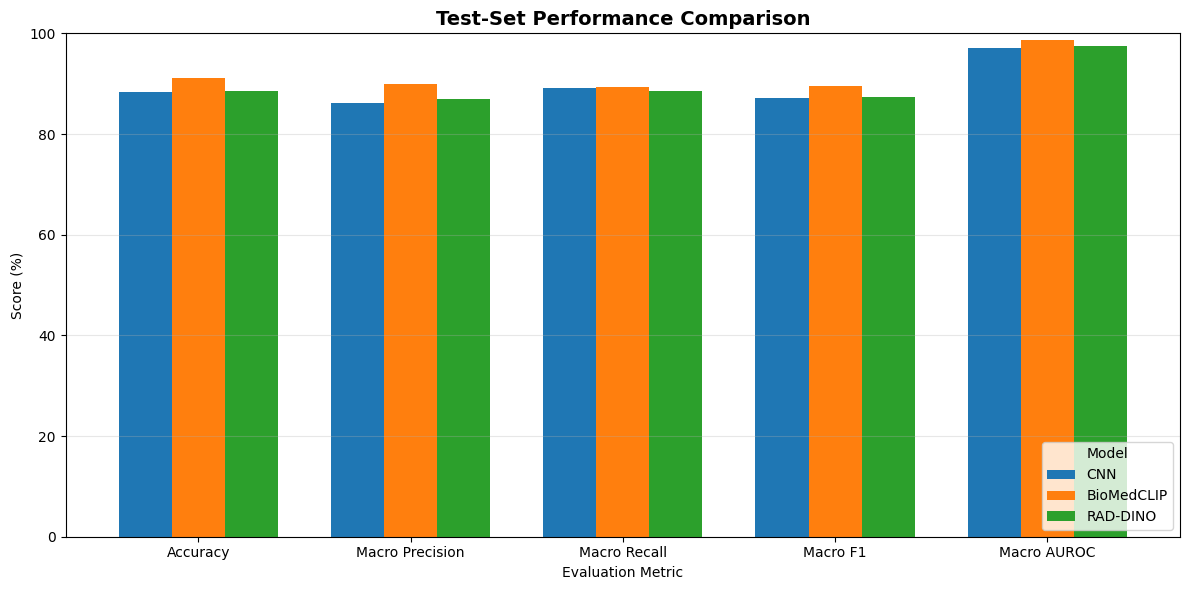

In [170]:
metrics_to_compare = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Macro AUROC"
]

comparison_df = pd.DataFrame({
    "CNN": [
        cnn_accuracy,
        cnn_precision,
        cnn_recall,
        cnn_f1,
        cnn_auroc
    ],

    "BioMedCLIP": [
        biomedclip_accuracy,
        biomedclip_precision,
        biomedclip_recall,
        biomedclip_f1,
        biomedclip_auroc
    ],

    "RAD-DINO": [
        raddino_accuracy,
        raddino_precision,
        raddino_recall,
        raddino_f1,
        raddino_auroc
    ]
}, index=metrics_to_compare)

# Convert to percentages only for visualization
comparison_percent = comparison_df * 100

ax = comparison_percent.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.75
)

ax.set_title(
    "Test-Set Performance Comparison",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Evaluation Metric")
ax.set_ylabel("Score (%)")

ax.set_ylim(0, 100)

ax.legend(
    title="Model",
    loc="lower right"
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

5.2 Confusion Matrix

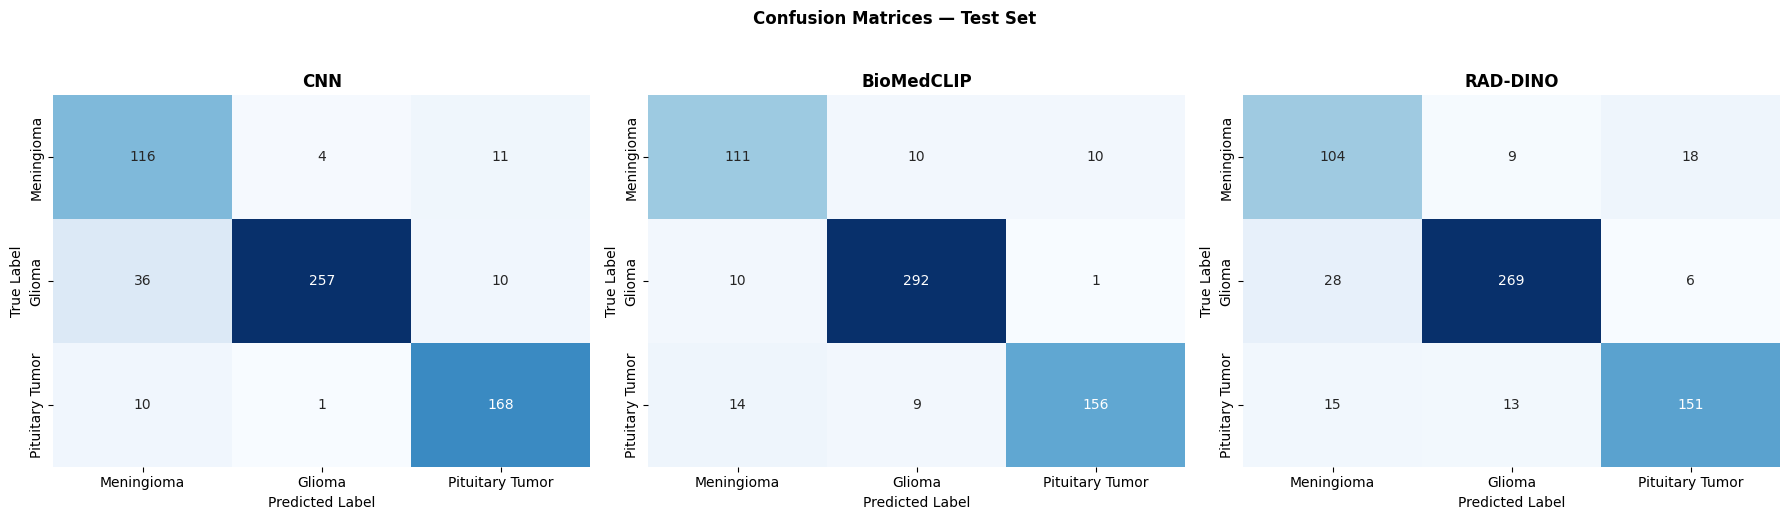

In [143]:
fig, axes = plt.subplots(1, len(model_results), figsize=(6 * len(model_results), 5))

for ax, (model_name, metrics) in zip(axes, model_results.items()):
    sns.heatmap(
        metrics['Confusion Matrix'], annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False
    )
    ax.set_title(model_name, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices — Test Set', fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

5.3 ROC Curves

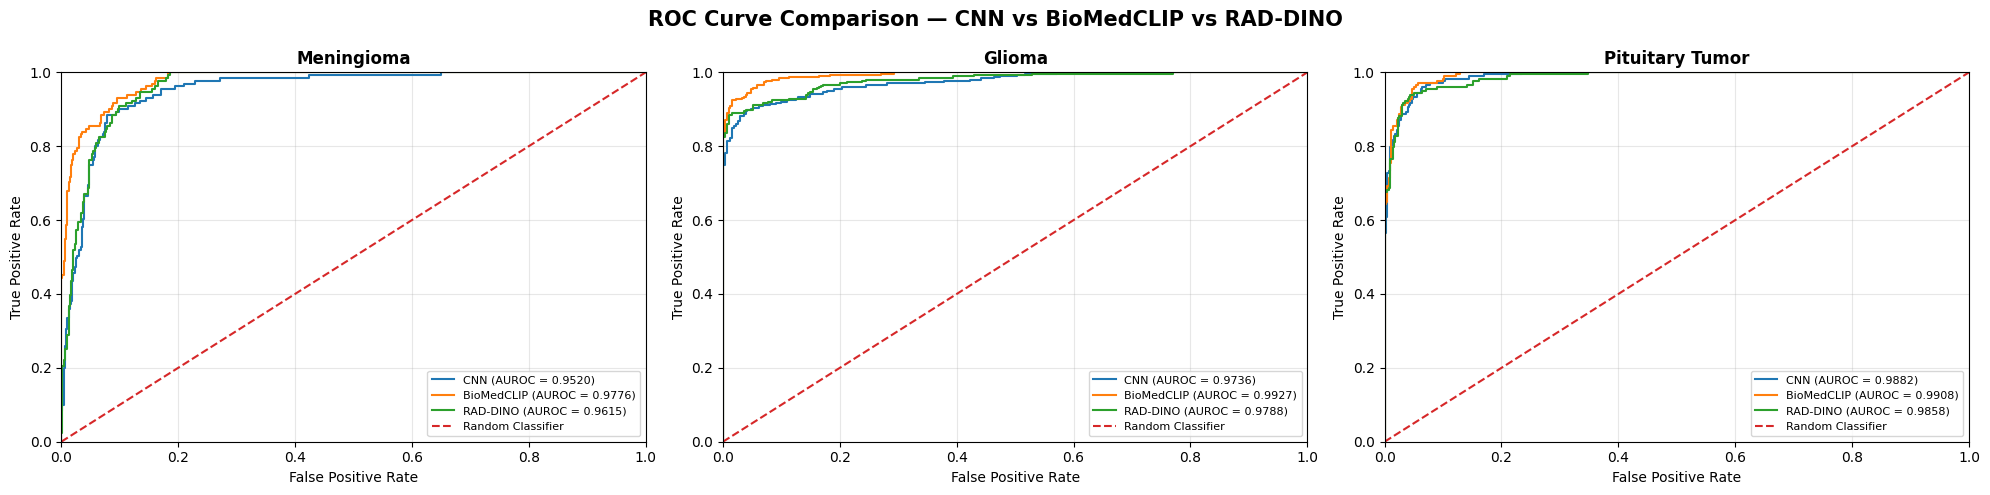

In [172]:
# ROC CURVE COMPARISON — CNN vs BioMedCLIP vs RAD-DINO

# Each graph represents ONE tumor class.
# Each graph contains the ROC curves of all THREE models.

# This allows us to compare how well the models distinguish:
# 1. Meningioma
# 2. Glioma
# 3. Pituitary Tumor

# AUROC values are shown between 0 and 1, which is the standard way of reporting AUROC.

class_names = [
    "Meningioma",
    "Glioma",
    "Pituitary Tumor"
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5)
)

# 1. MENINGIOMA
axes[0].plot(
    cnn_roc_fpr[0],
    cnn_roc_tpr[0],
    label=f"CNN (AUROC = {cnn_class_auroc[0]:.4f})"
)

axes[0].plot(
    biomedclip_roc_fpr[0],
    biomedclip_roc_tpr[0],
    label=f"BioMedCLIP (AUROC = {biomedclip_class_auroc[0]:.4f})"
)

axes[0].plot(
    raddino_roc_fpr[0],
    raddino_roc_tpr[0],
    label=f"RAD-DINO (AUROC = {raddino_class_auroc[0]:.4f})"
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

axes[0].set_title(
    "Meningioma",
    fontweight="bold"
)

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")

axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

axes[0].legend(
    loc="lower right",
    fontsize=8
)

axes[0].grid(alpha=0.3)

# 2. GLIOMA
axes[1].plot(
    cnn_roc_fpr[1],
    cnn_roc_tpr[1],
    label=f"CNN (AUROC = {cnn_class_auroc[1]:.4f})"
)

axes[1].plot(
    biomedclip_roc_fpr[1],
    biomedclip_roc_tpr[1],
    label=f"BioMedCLIP (AUROC = {biomedclip_class_auroc[1]:.4f})"
)

axes[1].plot(
    raddino_roc_fpr[1],
    raddino_roc_tpr[1],
    label=f"RAD-DINO (AUROC = {raddino_class_auroc[1]:.4f})"
)

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

axes[1].set_title(
    "Glioma",
    fontweight="bold"
)

axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")

axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

axes[1].legend(
    loc="lower right",
    fontsize=8
)

axes[1].grid(alpha=0.3)

# 3. PITUITARY TUMOR
axes[2].plot(
    cnn_roc_fpr[2],
    cnn_roc_tpr[2],
    label=f"CNN (AUROC = {cnn_class_auroc[2]:.4f})"
)

axes[2].plot(
    biomedclip_roc_fpr[2],
    biomedclip_roc_tpr[2],
    label=f"BioMedCLIP (AUROC = {biomedclip_class_auroc[2]:.4f})"
)

axes[2].plot(
    raddino_roc_fpr[2],
    raddino_roc_tpr[2],
    label=f"RAD-DINO (AUROC = {raddino_class_auroc[2]:.4f})"
)

axes[2].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

axes[2].set_title(
    "Pituitary Tumor",
    fontweight="bold"
)

axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")

axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)

axes[2].legend(
    loc="lower right",
    fontsize=8
)

axes[2].grid(alpha=0.3)

plt.suptitle(
    "ROC Curve Comparison — CNN vs BioMedCLIP vs RAD-DINO",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

5.3 Final Model Selection

Observation: Overall Observation: BioMedCLIP was selected as the best-performing model for the JCBTD multi-class brain tumor classification task. It achieved the highest Accuracy (91.19%), Macro Precision (89.84%), Macro F1-score (89.58%), and Macro AUROC (0.9870), while also achieving the highest Macro Recall (89.42%). Although CNN achieved a very similar recall (89.07%), BioMedCLIP provided a better overall balance between precision and recall, reflected by its higher Macro F1-score. Its superior Macro AUROC also indicates stronger overall discrimination between the three tumor classes. Since this is a medical classification task, particular importance was given to recall and Macro F1-score because missed tumor cases (false negatives) are clinically important, while macro-averaging ensures that each tumor class contributes equally despite the class imbalance. Therefore, BioMedCLIP was selected as the final model because it provided the strongest and most balanced performance across the evaluation criteria.

In [1]:
import torch

# Save the trained weights to a file named 'biomedclip_classifier.pth'
torch.save(biomedclip_classifier.state_dict(), "biomedclip_classifier.pth")

NameError: name 'biomedclip_classifier' is not defined